In [1]:
# ==============================================================================
# CELL 1: SETUP AND IMPORTS
# ==============================================================================

# Standard Library
import os
import shutil
import random
import itertools
import time

# Numerical & Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch & Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR
import timm

# Scikit-Learn (Machine Learning)
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.model_selection import train_test_split

# Extra ML/Stats Tools
from scipy.special import softmax
from sklearn.manifold import TSNE

# Progress Bar
from tqdm import tqdm

# Kaggle
import kagglehub

print("All libraries imported successfully.")


/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

All libraries imported successfully.


In [2]:
# ==============================================================================
# CELL 2: DOWNLOAD AND PREPARE DATASET
# ==============================================================================
# --- Download from Kaggle ---
path = kagglehub.dataset_download("mdriyadhossain/ai-medleafx")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/


In [3]:
dataset_path = "/kaggle/input/"
print("Verified path to dataset files:", dataset_path)

# Assuming the structure is dataset_path -> 'Resized Image' -> Plant Type -> Disease/Health Status -> Images
resized_image_base_path = os.path.join(dataset_path, 'Resized Image')

all_class_dirs = []
class_counts = {}

print("\nExploring dataset structure and counting images:")

try:
    # List plant type directories within 'Resized Image'
    plant_type_dirs = [d for d in os.listdir(resized_image_base_path) if os.path.isdir(os.path.join(resized_image_base_path, d))]
    print(f"\nFound {len(plant_type_dirs)} plant types:", plant_type_dirs)

    if not plant_type_dirs:
        print("No plant type directories found within 'Resized Image'. Cannot proceed with expected structure.")
    else:
        # Iterate through each plant type directory
        for plant_type_dir in plant_type_dirs:
            plant_type_path = os.path.join(resized_image_base_path, plant_type_dir)

            # List disease/health status directories within each plant type
            status_dirs = [d for d in os.listdir(plant_type_path) if os.path.isdir(os.path.join(plant_type_path, d))]
            print(f"\nExploring '{plant_type_dir}': Found {len(status_dirs)} status categories:", status_dirs)

            if not status_dirs:
                print(f"No status directories found within '{plant_type_dir}'.")
            else:
                # Iterate through each status directory (these are the actual classes)
                for status_dir in status_dirs:
                    class_name = f"{plant_type_dir}_{status_dir}" # Combine plant type and status for a unique class name
                    class_path = os.path.join(plant_type_path, status_dir)
                    all_class_dirs.append(class_name)

                    # Count image files in the class directory
                    image_files_in_class = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg','.JPG'))]
                    class_counts[class_name] = len(image_files_in_class)
                    print(f"- {class_name}: {class_counts[class_name]} images")

        # Determine the total number of classes
        num_classes = len(all_class_dirs)
        print(f"\nTotal number of classes: {num_classes}")

        # Display class distribution summary
        print("\nClass distribution:")
        for class_name, count in class_counts.items():
            print(f"- {class_name}: {count}")

        # Calculate total number of images
        total_images = sum(class_counts.values())
        print(f"\nTotal number of images: {total_images}")

except FileNotFoundError:
    print(f"Error: The directory '{resized_image_base_path}' was not found.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


print("\nDataset exploration and counting complete.")

Verified path to dataset files: /kaggle/input/

Exploring dataset structure and counting images:

Found 4 plant types: ['Sojina', 'Neem', 'Camphor', 'HariTaki']

Exploring 'Sojina': Found 3 status categories: ['Yellow Leaf', 'Healthy Leaf', 'Bacterial Spot']
- Sojina_Yellow Leaf: 814 images
- Sojina_Healthy Leaf: 860 images
- Sojina_Bacterial Spot: 804 images

Exploring 'Neem': Found 4 status categories: ['Powdery Mildew', 'Yellow Leaf', 'Healthy Leaf', 'Shot Hole Leaf']
- Neem_Powdery Mildew: 854 images
- Neem_Yellow Leaf: 854 images
- Neem_Healthy Leaf: 1021 images
- Neem_Shot Hole Leaf: 834 images

Exploring 'Camphor': Found 3 status categories: ['Healthy Leaf', 'Shot Hole', 'Bacterial Spot']
- Camphor_Healthy Leaf: 800 images
- Camphor_Shot Hole: 795 images
- Camphor_Bacterial Spot: 801 images

Exploring 'HariTaki': Found 3 status categories: ['Healthy Leaf', 'Shot Hole', 'Bacterial Spot']
- HariTaki_Healthy Leaf: 816 images
- HariTaki_Shot Hole: 802 images
- HariTaki_Bacterial Spo

In [4]:
# ==============================================================================
# CELL 3: DATA SPLITTING
# ==============================================================================

# Define paths
original_base_dir = os.path.join(dataset_path, 'Resized Image')
new_base_dir = '/content/data'

# Collect image paths and labels
data = []
for plant in os.listdir(original_base_dir):
    for status in os.listdir(os.path.join(original_base_dir, plant)):
        label = f"{plant}_{status}"
        path = os.path.join(original_base_dir, plant, status)
        for fname in os.listdir(path):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png','.JPG')):
                data.append({'path': os.path.join(path, fname), 'label': label})

df = pd.DataFrame(data)

# Split dataset: 80% train, 10% val, 10% test
train_val, test = train_test_split(df, test_size=0.1, stratify=df['label'], random_state=42)
train, val = train_test_split(train_val, test_size=0.1, stratify=train_val['label'], random_state=42)
# Output summary
total = len(df)
print(f"\n Dataset Split Summary:")
print(f"- Total images: {total}")
print(f"- Training set : {len(train):5d} images ({len(train)/total:.1%})")
print(f"- Validation set: {len(val):5d} images ({len(val)/total:.1%})")
print(f"- Test set     : {len(test):5d} images ({len(test)/total:.1%})\n")

# Copy files
for split_df, split in zip([train, val, test], ['train', 'val', 'test']):
    print(f" Copying {split} files...")
    for _, row in split_df.iterrows():
        dst_dir = os.path.join(new_base_dir, split, row['label'])
        os.makedirs(dst_dir, exist_ok=True)
        shutil.copy(row['path'], os.path.join(dst_dir, os.path.basename(row['path'])))
    print(f" {split.capitalize()} files copied: {len(split_df)}")

print("\n All files have been split and copied successfully.")


 Dataset Split Summary:
- Total images: 10858
- Training set :  8794 images (81.0%)
- Validation set:   978 images (9.0%)
- Test set     :  1086 images (10.0%)

 Copying train files...
 Train files copied: 8794
 Copying val files...
 Val files copied: 978
 Copying test files...
 Test files copied: 1086

 All files have been split and copied successfully.


In [5]:
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [6]:
# ============================================================================
# DATA LOADING
# ============================================================================
from torch.utils.data import Dataset
from PIL import Image

class ImageDataset(Dataset):
    """Custom dataset for image classification"""
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label


def get_dinov2_transforms(is_training=False, img_size=224):
    """Get DINOv2-specific transforms"""
    if is_training:
        return transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    else:
        return transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

In [7]:


class DINOv2FeatureExtractor(nn.Module):
    """
    DINOv2 Vision Transformer as a feature extractor
    Base model: ViT-Base/14 trained on LVD-142M dataset
    """
    def __init__(self, model_name='vit_base_patch14_dinov2.lvd142m', pretrained=True, freeze_backbone=True):
        super().__init__()

        # Load pretrained DINOv2 model
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=0)

        # Freeze backbone if specified
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        # Get feature dimension
        self.feature_dim = self.backbone.num_features

    def forward(self, x):
        """Extract features from images"""
        return self.backbone(x)


class DINOv2Classifier(nn.Module):
    """
    Complete DINOv2 model with classification head
    """
    def __init__(self, num_classes, model_name='vit_base_patch14_dinov2.lvd142m',
                 pretrained=True, freeze_backbone=True, dropout=0.1):
        super().__init__()

        # Feature extractor
        self.feature_extractor = DINOv2FeatureExtractor(
            model_name=model_name,
            pretrained=pretrained,
            freeze_backbone=freeze_backbone
        )

        # Classification head
        self.classifier = nn.Sequential(
            nn.LayerNorm(self.feature_extractor.feature_dim),
            nn.Dropout(dropout),
            nn.Linear(self.feature_extractor.feature_dim, num_classes)
        )

    def forward(self, x):
        features = self.feature_extractor(x)
        logits = self.classifier(features)
        return logits

    def get_features(self, x):
        """Extract features without classification"""
        return self.feature_extractor(x)

In [8]:
# ============================================================================
# TRAINING SETUP
# ============================================================================

def create_model(num_classes, freeze_backbone=True, model_variant='base'):
    """
    Create DINOv2 model with different variants

    Args:
        num_classes: Number of output classes
        freeze_backbone: Whether to freeze the backbone
        model_variant: 'small', 'base', 'large', or 'giant'
    """
    model_names = {
        'small': 'vit_small_patch14_dinov2.lvd142m',
        'base': 'vit_base_patch14_dinov2.lvd142m',
        'large': 'vit_large_patch14_dinov2.lvd142m',
        'giant': 'vit_giant_patch14_dinov2.lvd142m'
    }

    model_name = model_names.get(model_variant, model_names['base'])

    model = DINOv2Classifier(
        num_classes=num_classes,
        model_name=model_name,
        pretrained=True,
        freeze_backbone=freeze_backbone,
        dropout=0.1
    )

    return model


# ============================================================================
# EXAMPLE USAGE
# ============================================================================

if __name__ == "__main__":
    # Example configuration (these variables are redefined globally later)
    # NUM_CLASSES is now defined globally after data loading setup
    BATCH_SIZE = 32
    IMG_SIZE = 518 # Changed from 224 to 518 to match DINOv2 model's expected input size
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # The actual model instantiation will happen globally after data loaders are set up
    # For the purpose of this __main__ block, we can keep this for testing model creation
    # For real use, ensure `model` and `NUM_CLASSES` are globally defined before this `if __name__` block
    # or pass them as arguments to functions that need them.

    # Placeholder for NUM_CLASSES if this block is run independently
    _num_classes_placeholder = 10 # This will be overridden by the global NUM_CLASSES

    # Instantiate the model for testing within this block
    model = create_model(
        num_classes=_num_classes_placeholder,
        freeze_backbone=True,
        model_variant='base'
    )
    model = model.to(DEVICE)

    print(f"Model created successfully!")
    print(f"Feature dimension: {model.feature_extractor.feature_dim}")
    print(f"Number of classes: {_num_classes_placeholder}") # Using placeholder for example

    # Example: Load and prepare data (these are not the actual datasets/loaders)
    train_image_paths = ['path/to/image1.jpg', 'path/to/image2.jpg']
    train_labels = [0, 1]

    train_transform = get_dinov2_transforms(is_training=True, img_size=IMG_SIZE)
    val_transform = get_dinov2_transforms(is_training=False, img_size=IMG_SIZE)

    # These example dataset/loader creations are commented out as they will be defined globally
    # train_dataset = ImageDataset(train_image_paths, train_labels, train_transform)
    # train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

    # Example forward pass
    dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    with torch.no_grad():
        output = model(dummy_input)
        features = model.get_features(dummy_input)

    print(f"\nOutput shape: {output.shape}")
    print(f"Features shape: {features.shape}")

    # Model summary
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"\nTotal parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Frozen parameters: {total_params - trainable_params:,}")

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Model created successfully!
Feature dimension: 768
Number of classes: 10

Output shape: torch.Size([1, 10])
Features shape: torch.Size([1, 768])

Total parameters: 86,588,938
Trainable parameters: 9,226
Frozen parameters: 86,579,712


In [9]:
# ============================================================================
# DEFINE GLOBAL VARIABLES FOR DATA LOADING AND MODEL
# ============================================================================

# Get the actual number of classes from the dataset exploration
NUM_CLASSES = len(all_class_dirs)
print(f"Global NUM_CLASSES set to: {NUM_CLASSES}")

# Create a mapping from class name string to integer label
class_to_idx = {class_name: i for i, class_name in enumerate(sorted(all_class_dirs))}
idx_to_class = {i: class_name for class_name, i in class_to_idx.items()}
print(f"Class mapping created: {class_to_idx}")

# Define device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# Instantiate the DINOv2 model globally
# Using 'base' variant and freezing backbone for feature extraction
m_model = create_model(
    num_classes=NUM_CLASSES,
    freeze_backbone=True,
    model_variant='base'
)
m_model = m_model.to(DEVICE)
print("Global DINOv2 model instantiated and moved to device.")

BATCH_SIZE = 32
IMG_SIZE = 518 # DINOv2 default input size


Global NUM_CLASSES set to: 13
Class mapping created: {'Camphor_Bacterial Spot': 0, 'Camphor_Healthy Leaf': 1, 'Camphor_Shot Hole': 2, 'HariTaki_Bacterial Spot': 3, 'HariTaki_Healthy Leaf': 4, 'HariTaki_Shot Hole': 5, 'Neem_Healthy Leaf': 6, 'Neem_Powdery Mildew': 7, 'Neem_Shot Hole Leaf': 8, 'Neem_Yellow Leaf': 9, 'Sojina_Bacterial Spot': 10, 'Sojina_Healthy Leaf': 11, 'Sojina_Yellow Leaf': 12}
Using device: cuda
Global DINOv2 model instantiated and moved to device.


In [10]:
# ============================================================================
# CREATE DATA LOADERS
# ============================================================================

# Get transforms
train_transform = get_dinov2_transforms(is_training=True, img_size=IMG_SIZE)
val_transform = get_dinov2_transforms(is_training=False, img_size=IMG_SIZE)
test_transform = get_dinov2_transforms(is_training=False, img_size=IMG_SIZE)

# Prepare lists of image paths and integer labels
def prepare_data_lists(dataframe, class_to_idx):
    paths = dataframe['path'].tolist()
    labels = [class_to_idx[label_str] for label_str in dataframe['label']]
    return paths, labels

# Create datasets
train_image_paths, train_labels_int = prepare_data_lists(train, class_to_idx)
val_image_paths, val_labels_int = prepare_data_lists(val, class_to_idx)
test_image_paths, test_labels_int = prepare_data_lists(test, class_to_idx)

train_dataset = ImageDataset(train_image_paths, train_labels_int, train_transform)
val_dataset = ImageDataset(val_image_paths, val_labels_int, val_transform)
test_dataset = ImageDataset(test_image_paths, test_labels_int, test_transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Train, Validation, and Test DataLoaders created successfully.")
print(f"Train DataLoader has {len(train_loader.dataset)} images.")
print(f"Validation DataLoader has {len(val_loader.dataset)} images.")
print(f"Test DataLoader has {len(test_loader.dataset)} images.")


Train, Validation, and Test DataLoaders created successfully.
Train DataLoader has 8794 images.
Validation DataLoader has 978 images.
Test DataLoader has 1086 images.


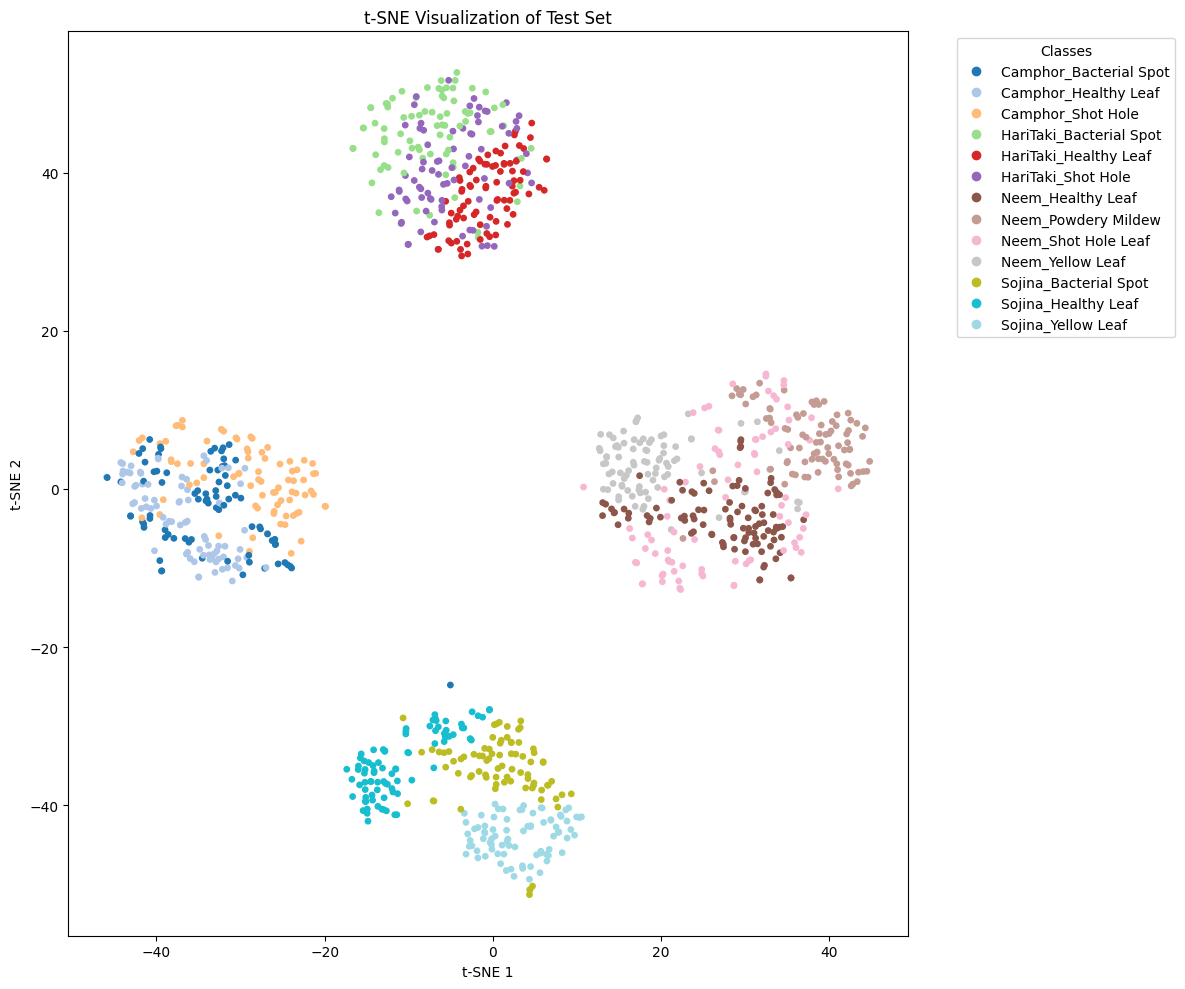

In [11]:
import torch
import numpy as np
from torch.utils.data import DataLoader
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# =========================================
# 1️⃣ Feature Extraction Function
# =========================================
def extract_features(model, loader, device='cuda'):
    model.eval()
    all_features = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            feats = model.get_features(images)  # Or model.forward_features(images)
            all_features.append(feats.cpu().numpy())
            all_labels.append(labels.numpy())
    all_features = np.concatenate(all_features, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    return all_features, all_labels

# =========================================
# 2️⃣ Extract Features from Test Loader
# =========================================
X_test, y_test = extract_features(model, test_loader, device='cuda')

# =========================================
# 3️⃣ t-SNE Dimensionality Reduction
# =========================================
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
X_test_tsne = tsne.fit_transform(X_test)

# =========================================
# 4️⃣ Map integer labels to class names
# =========================================
# Suppose you have class_to_idx mapping from training
idx_to_class = {v: k for k, v in class_to_idx.items()}  # invert dictionary
y_test_names = [idx_to_class[i] for i in y_test]

# =========================================
# 5️⃣ Plot t-SNE with class names
# =========================================
plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_test_tsne[:, 0], X_test_tsne[:, 1], c=y_test, cmap='tab20', s=15)

# Create legend with actual class names
handles, _ = scatter.legend_elements()
unique_labels = np.unique(y_test)
plt.legend(handles, [idx_to_class[i] for i in unique_labels], title="Classes",
           bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title("t-SNE Visualization of Test Set")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()


In [12]:
# ============================================================================
# 1. FEATURE EXTRACTION
# ============================================================================
def extract_features(model, dataloader, device):
    model.eval()
    all_features = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Extracting features"):
            images = images.to(device)
            feats = model.get_features(images)
            all_features.append(feats.cpu().numpy())
            all_labels.append(labels.numpy())

    all_features = np.concatenate(all_features, axis=0)
    all_labels   = np.concatenate(all_labels, axis=0)
    return all_features, all_labels


# Extract train features only
train_X, train_y = extract_features(model, train_loader, DEVICE)


# ============================================================================
# 2. STANDARDIZE FEATURES
# ============================================================================
scaler = StandardScaler()
train_X = scaler.fit_transform(train_X)


# ============================================================================
# 3. PCA DIMENSIONALITY REDUCTION
# ============================================================================
pca = PCA(n_components=512)
train_X = pca.fit_transform(train_X)


# ============================================================================
# 4. TRAIN MLP CLASSIFIER
# ============================================================================
mlp = MLPClassifier(
    hidden_layer_sizes=(1024, 512, 256),
    activation='relu',
    solver='adam',
    learning_rate_init=0.00001,
    max_iter=1400,
    random_state=42,
    verbose=True
)

mlp.fit(train_X, train_y)


# ============================================================================
# 5. TEST ACCURACY (ONLY)
# ============================================================================
# Extract test features
test_X, test_y = extract_features(model, test_loader, DEVICE)

# Apply same StandardScaler and PCA
test_X = scaler.transform(test_X)
test_X = pca.transform(test_X)

# Predict on test set
test_preds = mlp.predict(test_X)
test_acc = accuracy_score(test_y, test_preds)

print(f"\nFinal Test Accuracy: {test_acc * 100:.2f}%")

Extracting features: 100%|██████████| 275/275 [07:45<00:00,  1.69s/it]


Iteration 1, loss = 2.46274855
Iteration 2, loss = 1.95996826
Iteration 3, loss = 1.56005281
Iteration 4, loss = 1.23477945
Iteration 5, loss = 0.98390119
Iteration 6, loss = 0.79913525
Iteration 7, loss = 0.66481239
Iteration 8, loss = 0.56587332
Iteration 9, loss = 0.49080499
Iteration 10, loss = 0.43244175
Iteration 11, loss = 0.38567766
Iteration 12, loss = 0.34745779
Iteration 13, loss = 0.31578225
Iteration 14, loss = 0.28898888
Iteration 15, loss = 0.26647424
Iteration 16, loss = 0.24648185
Iteration 17, loss = 0.22929155
Iteration 18, loss = 0.21401069
Iteration 19, loss = 0.20070238
Iteration 20, loss = 0.18866443
Iteration 21, loss = 0.17763783
Iteration 22, loss = 0.16802629
Iteration 23, loss = 0.15914522
Iteration 24, loss = 0.15078359
Iteration 25, loss = 0.14350841
Iteration 26, loss = 0.13658490
Iteration 27, loss = 0.13033586
Iteration 28, loss = 0.12441446
Iteration 29, loss = 0.11899677
Iteration 30, loss = 0.11419383
Iteration 31, loss = 0.10923972
Iteration 32, los

Extracting features: 100%|██████████| 34/34 [00:57<00:00,  1.69s/it]


Final Test Accuracy: 96.87%


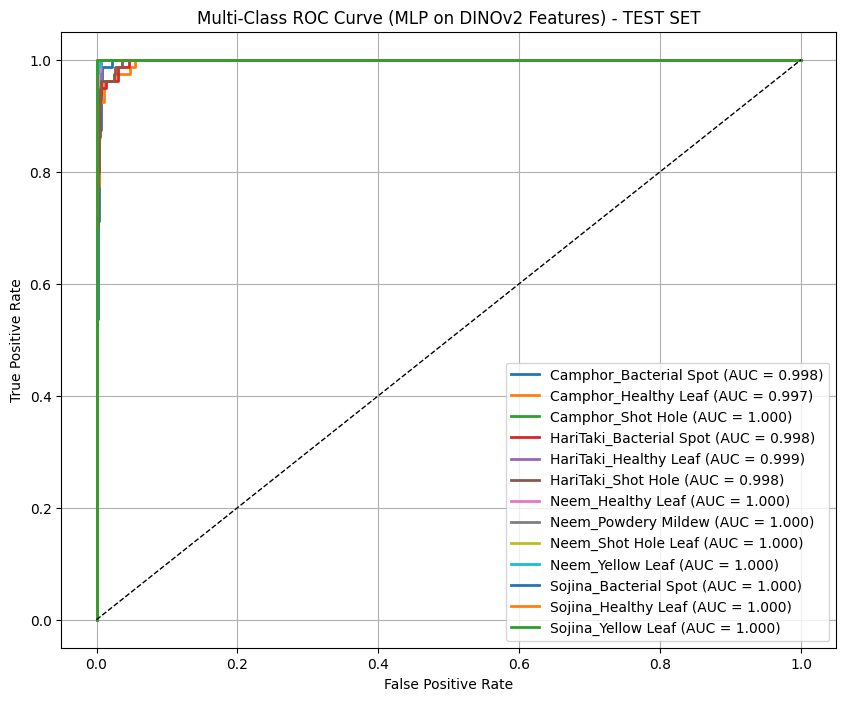

In [13]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# ===============================================
# 1. Probability Predictions on TEST SET
# ===============================================
probs = mlp.predict_proba(test_X)     # shape = (N, NUM_CLASSES)
labels = test_y                       # true labels


# ===============================================
# 2. Binarize labels for Multi-Class ROC
# ===============================================
y_bin = label_binarize(labels, classes=list(range(NUM_CLASSES)))


# ===============================================
# 3. Plot ROC Curve for Each Class
# ===============================================
plt.figure(figsize=(10, 8))

class_names = list(class_to_idx.keys())  # optional, for prettier legends

for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
    roc_auc = auc(fpr, tpr)

    if class_names:
        label = f"{class_names[i]} (AUC = {roc_auc:.3f})"
    else:
        label = f"Class {i} (AUC = {roc_auc:.3f})"

    plt.plot(fpr, tpr, lw=2, label=label)


# ===============================================
# 4. Formatting
# ===============================================
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve (MLP on DINOv2 Features) - TEST SET")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()



✔️ Overall Test Accuracy: 96.87%

📌 Per-Class Test Accuracy:
                         Accuracy (%)
Camphor_Bacterial Spot          98.75
Camphor_Healthy Leaf            88.75
Camphor_Shot Hole               96.25
HariTaki_Bacterial Spot         83.75
HariTaki_Healthy Leaf          100.00
HariTaki_Shot Hole              96.25
Neem_Healthy Leaf               98.04
Neem_Powdery Mildew             98.84
Neem_Shot Hole Leaf             98.80
Neem_Yellow Leaf                98.84
Sojina_Bacterial Spot          100.00
Sojina_Healthy Leaf            100.00
Sojina_Yellow Leaf             100.00

📄 Test Classification Report:
                         precision  recall  f1-score   support
Camphor_Bacterial Spot       0.888   0.988     0.935    80.000
Camphor_Healthy Leaf         0.959   0.888     0.922    80.000
Camphor_Shot Hole            1.000   0.962     0.981    80.000
HariTaki_Bacterial Spot      0.985   0.838     0.905    80.000
HariTaki_Healthy Leaf        0.921   1.000     0.959    82.0

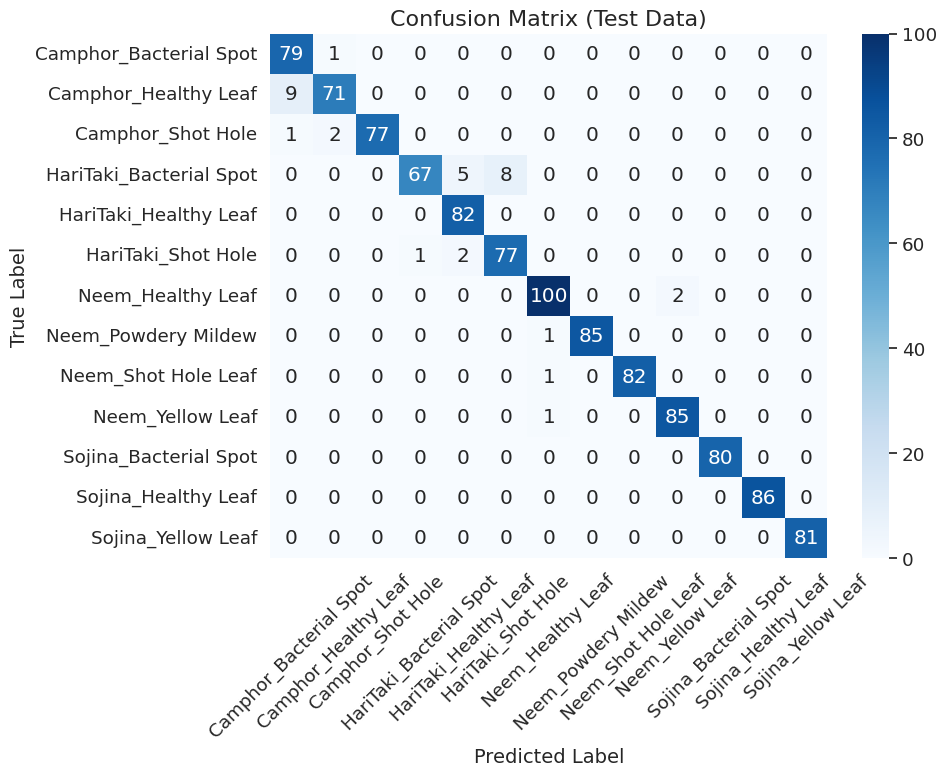

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ------------------------------
# 1. Predictions on TEST SET
# ------------------------------
preds = mlp.predict(test_X)

# ------------------------------
# 2. Overall Accuracy
# ------------------------------
overall_acc = accuracy_score(test_y, preds)
print(f"\n✔️ Overall Test Accuracy: {overall_acc * 100:.2f}%")

# ------------------------------
# 3. Per-Class Accuracy
# ------------------------------
per_class_acc = {}
for c in range(NUM_CLASSES):
    idx = np.where(test_y == c)[0]  # indices of class c
    class_acc = accuracy_score(test_y[idx], preds[idx])
    class_name = list(class_to_idx.keys())[c]
    per_class_acc[class_name] = class_acc * 100

# Display per-class accuracy
df_acc = pd.DataFrame.from_dict(per_class_acc, orient='index', columns=['Accuracy (%)'])
df_acc = df_acc.sort_index()
print("\n📌 Per-Class Test Accuracy:")
print(df_acc.to_string(float_format='%.2f'))

# ------------------------------
# 4. Classification Report (Precision, Recall, F1)
# ------------------------------
print("\n📄 Test Classification Report:")
report = classification_report(
    test_y, preds,
    target_names=list(class_to_idx.keys()),
    digits=3,
    output_dict=True
)
df_report = pd.DataFrame(report).T
print(df_report.round(3))

# Macro averages
macro_precision = precision_score(test_y, preds, average='macro')
macro_recall = recall_score(test_y, preds, average='macro')
macro_f1 = f1_score(test_y, preds, average='macro')

print(f"\n🔹 Macro Precision: {macro_precision:.3f}")
print(f"🔹 Macro Recall:    {macro_recall:.3f}")
print(f"🔹 Macro F1-score:  {macro_f1:.3f}")

# ------------------------------
# 5. Confusion Matrix Visualization
# ------------------------------
cm = confusion_matrix(test_y, preds)
plt.figure(figsize=(10, 8))
sns.set(font_scale=1.2)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=list(class_to_idx.keys()),
    yticklabels=list(class_to_idx.keys()),
    cbar=True
)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.title('Confusion Matrix (Test Data)', fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Iteration 1, loss = 1.16687936
Iteration 2, loss = 0.28231392
Iteration 3, loss = 0.15666868
Iteration 4, loss = 0.10750522
Iteration 5, loss = 0.07920877
Iteration 6, loss = 0.06183970
Iteration 7, loss = 0.04815859
Iteration 8, loss = 0.03763455
Iteration 9, loss = 0.03051602
Iteration 10, loss = 0.02500393
Iteration 11, loss = 0.02054301
Iteration 12, loss = 0.01742567
Iteration 13, loss = 0.01463544
Iteration 14, loss = 0.01228890
Iteration 15, loss = 0.01075755
Iteration 16, loss = 0.00952249
Iteration 17, loss = 0.00786416
Iteration 18, loss = 0.00671288
Iteration 19, loss = 0.00587655
Iteration 20, loss = 0.00543859
Iteration 21, loss = 0.00488675
Iteration 22, loss = 0.00420766
Iteration 23, loss = 0.00370454
Iteration 24, loss = 0.00338161
Iteration 25, loss = 0.00307630
Iteration 26, loss = 0.00281688
Iteration 27, loss = 0.00260676
Iteration 28, loss = 0.00241127
Iteration 29, loss = 0.00224777
Iteration 30, loss = 0.00209873
Iteration 31, loss = 0.00197070
Iteration 32, los

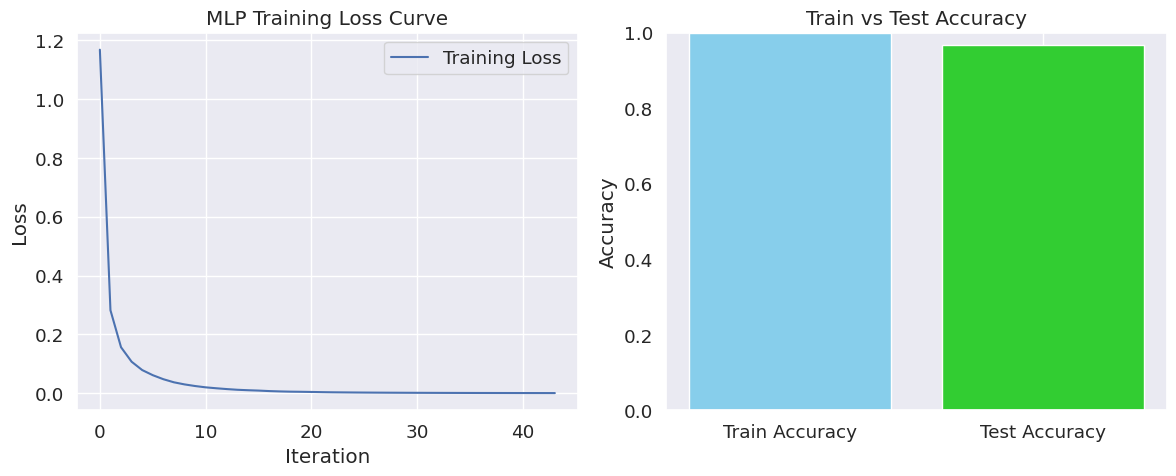

In [15]:
import time
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# ------------------------------
# 1. Track Train Loss & Accuracy
# ------------------------------

train_losses = []
train_accuracies = []

# ------------------------------
# 2. Timing
# ------------------------------
start_time = time.time()

mlp = MLPClassifier(
    hidden_layer_sizes=(1024, 512, 256),
    activation='relu',
    solver='adam',
    learning_rate_init=0.0001,
    max_iter=1000,
    random_state=42,
    verbose=True
)

mlp_start = time.time()
mlp.fit(train_X, train_y)
mlp_end = time.time()

train_time = mlp_end - mlp_start

# ------------------------------
# 3. Evaluate on Train & TEST for Learning Curve
# ------------------------------
# Training accuracy
train_preds = mlp.predict(train_X)
train_acc = accuracy_score(train_y, train_preds)

# Test accuracy
test_preds = mlp.predict(test_X)
test_acc = accuracy_score(test_y, test_preds)

# Save metrics
train_accuracies.append(train_acc)

# sklearn MLP does not compute test loss per epoch
train_losses = mlp.loss_curve_

end_time = time.time()
total_time = end_time - start_time

print(f"\n⏱ Training Time: {train_time:.2f} sec")
print(f"⏱ Total Execution Time (including eval): {total_time:.2f} sec")
print(f"\n✔ Train Accuracy: {train_acc*100:.2f}%")
print(f"✔ Test Accuracy:  {test_acc*100:.2f}%")

# ------------------------------
# 4. Plot Learning Curves
# ------------------------------
plt.figure(figsize=(12, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Training Loss")
plt.title("MLP Training Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

# Train vs Test Accuracy
plt.subplot(1, 2, 2)
plt.bar(['Train Accuracy', 'Test Accuracy'],
        [train_acc, test_acc],
        color=['skyblue', 'limegreen'])
plt.ylim(0, 1)
plt.title("Train vs Test Accuracy")
plt.ylabel("Accuracy")
plt.grid(axis='y')

plt.tight_layout()
plt.show()


In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# ------------------------------
# 1. Define k values
# ------------------------------
k_values = [1, 5, 20]

# ------------------------------
# 2. Evaluate k-NN for each k
# ------------------------------
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='cosine')  # cosine works well for embeddings
    knn.fit(train_X, train_y)

    # Predict on TEST set
    test_preds = knn.predict(test_X)
    acc = accuracy_score(test_y, test_preds)

    print(f"k = {k}: Test Accuracy = {acc * 100:.2f}%")


k = 1: Test Accuracy = 89.78%
k = 5: Test Accuracy = 87.48%
k = 20: Test Accuracy = 86.83%


✅ 1% labeled data (87 samples): Test Accuracy = 65.65%
✅ 5% labeled data (439 samples): Test Accuracy = 84.90%
✅ 10% labeled data (879 samples): Test Accuracy = 90.61%
✅ 25% labeled data (2198 samples): Test Accuracy = 94.11%
✅ 50% labeled data (4397 samples): Test Accuracy = 95.76%


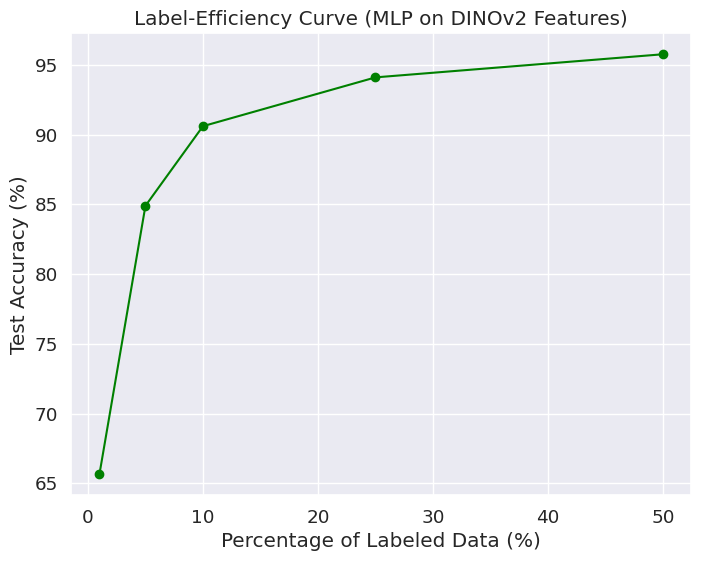

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# ------------------------------
# 1. Define labeled fractions
# ------------------------------
fractions = [0.01, 0.05, 0.10, 0.25, 0.50]  # 1%, 5%, 10%, 25%, 50%
n_train = train_X.shape[0]

mlp_accuracies = []

# ------------------------------
# 2. Train MLP on subsets
# ------------------------------
for frac in fractions:
    n_samples = max(1, int(n_train * frac))  # at least 1 sample
    np.random.seed(42)
    indices = np.random.choice(n_train, n_samples, replace=False)

    X_subset = train_X[indices]
    y_subset = train_y[indices]

    # MLP classifier
    mlp_subset = MLPClassifier(
        hidden_layer_sizes=(1024, 512, 256),
        activation='relu',
        solver='adam',
        learning_rate_init=0.0001,
        max_iter=1000,
        random_state=42,
        verbose=False
    )

    mlp_subset.fit(X_subset, y_subset)

    # Evaluate on test set
    test_preds = mlp_subset.predict(test_X)
    acc = accuracy_score(test_y, test_preds)

    mlp_accuracies.append(acc)
    print(f"✅ {frac*100:.0f}% labeled data ({n_samples} samples): Test Accuracy = {acc*100:.2f}%")

# ------------------------------
# 3. Plot Label-Efficiency Curve
# ------------------------------
plt.figure(figsize=(8,6))
plt.plot([f*100 for f in fractions], [a*100 for a in mlp_accuracies], marker='o', color='green')
plt.xlabel("Percentage of Labeled Data (%)")
plt.ylabel("Test Accuracy (%)")
plt.title("Label-Efficiency Curve (MLP on DINOv2 Features)")
plt.grid(True)
plt.show()
